# Descriptive analysis

This notebook summarises the formal 3 × 3 experiment before inferential
testing. It reports software-quality outcomes, efficiency metrics and
automated-refinement behaviour without removing any runs or constructing a
composite quality score.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.3f}")

analysis_dir = Path.cwd().parent
outputs_dir = analysis_dir / "outputs"
tables_dir = analysis_dir / "tables"
figures_dir = analysis_dir / "figures"

tables_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

runs = pd.read_csv(
    outputs_dir / "processed_runs.csv",
    parse_dates=["startedAt", "completedAt"],
)

iterations = pd.read_csv(
    outputs_dir / "processed_iterations.csv"
)

print("Run-level rows:", len(runs))
print("Iteration-level rows:", len(iterations))

Matplotlib is building the font cache; this may take a moment.


Run-level rows: 90
Iteration-level rows: 125


In [4]:
design_table = pd.crosstab(
    runs["specificationId"],
    runs["workflow"],
    margins=True,
)

design_table

assert len(runs) == 90
assert (
    pd.crosstab(
        runs["specificationId"],
        runs["workflow"],
    )
    == 10
).all().all()

print("Balanced 3 × 3 design: PASSED")

Balanced 3 × 3 design: PASSED


In [29]:
overall_outcomes = pd.DataFrame(
    {
        "outcome": [
            "Final all checks passed",
            "Final static analysis passed",
            "Final runtime validation passed",
            "Final accessibility validation passed",
            "Final functional validation passed",
        ],
        "passed": [
            runs["finalAllPassed"].sum(),
            runs["finalStaticPassed"].sum(),
            runs["finalRuntimePassed"].sum(),
            runs["finalAccessibilityPassed"].sum(),
            runs["finalFunctionalPassed"].sum(),
        ],
    }
)

overall_outcomes["total"] = len(runs)
overall_outcomes["percentage"] = (
    overall_outcomes["passed"]
    / overall_outcomes["total"]
    * 100
)

overall_outcomes



,outcome,passed,total,percentage
0,Final all checks passed,51,90,56.667
1,Final static analysis passed,64,90,71.111
2,Final runtime validation passed,89,90,98.889
3,Final accessibility validation passed,63,90,70.000
4,Final functional validation passed,86,90,95.556


In [30]:
overall_outcomes.to_csv(
    tables_dir / "descriptive_overall_pass_outcomes.csv",
    index=False,
)

In [7]:
pass_columns = [
    "finalAllPassed",
    "finalStaticPassed",
    "finalRuntimePassed",
    "finalAccessibilityPassed",
    "finalFunctionalPassed",
]

workflow_pass_counts = (
    runs.groupby("workflow")[pass_columns]
    .agg(["sum", "count"])
)

workflow_pass_counts

finalAllPassed       finalStaticPassed        \
                                sum count               sum count   
workflow                                                            
automated-refinement             30    30                30    30   
one-shot                          2    30                14    30   
quality-focused                  19    30                20    30   

                     finalRuntimePassed       finalAccessibilityPassed        \
                                    sum count                      sum count   
workflow                                                                       
automated-refinement                 30    30                       30    30   
one-shot                             30    30                        3    30   
quality-focused                      29    30                       30    30   

                     finalFunctionalPassed        
                                       sum count  
workflow                                          
automated-refinement                    30    30  
one-shot                                29    30  
quality-focused                         27    30

In [8]:
workflow_pass_summary = []

for workflow, group in runs.groupby("workflow"):
    for outcome in pass_columns:
        passed = int(group[outcome].sum())
        total = len(group)

        workflow_pass_summary.append(
            {
                "workflow": workflow,
                "outcome": outcome,
                "passed": passed,
                "failed": total - passed,
                "total": total,
                "percentagePassed": passed / total * 100,
            }
        )

workflow_pass_summary = pd.DataFrame(workflow_pass_summary)

workflow_pass_summary

,workflow,outcome,passed,failed,total,percentagePassed
0,automated-refinement,finalAllPassed,30,0,30,100.000
1,automated-refinement,finalStaticPassed,30,0,30,100.000
2,automated-refinement,finalRuntimePassed,30,0,30,100.000
3,automated-refinement,finalAccessibilityPassed,30,0,30,100.000
4,automated-refinement,finalFunctionalPassed,30,0,30,100.000
5,one-shot,finalAllPassed,2,28,30,6.667
6,one-shot,finalStaticPassed,14,16,30,46.667
7,one-shot,finalRuntimePassed,30,0,30,100.000
8,one-shot,finalAccessibilityPassed,3,27,30,10.000
9,one-shot,finalFunctionalPassed,29,1,30,96.667


In [9]:
workflow_pass_summary.to_csv(
    tables_dir / "descriptive_pass_outcomes_by_workflow.csv",
    index=False,
)

In [10]:
cell_pass_summary = []

for (specification, workflow), group in runs.groupby(
    ["specificationId", "workflow"]
):
    for outcome in pass_columns:
        passed = int(group[outcome].sum())
        total = len(group)

        cell_pass_summary.append(
            {
                "specificationId": specification,
                "workflow": workflow,
                "outcome": outcome,
                "passed": passed,
                "failed": total - passed,
                "total": total,
                "percentagePassed": passed / total * 100,
            }
        )

cell_pass_summary = pd.DataFrame(cell_pass_summary)

cell_pass_summary.head(15)

,specificationId,workflow,outcome,passed,failed,total,percentagePassed
0,booking,automated-refinement,finalAllPassed,10,0,10,100.000
1,booking,automated-refinement,finalStaticPassed,10,0,10,100.000
2,booking,automated-refinement,finalRuntimePassed,10,0,10,100.000
3,booking,automated-refinement,finalAccessibilityPassed,10,0,10,100.000
4,booking,automated-refinement,finalFunctionalPassed,10,0,10,100.000
5,booking,one-shot,finalAllPassed,0,10,10,0.000
6,booking,one-shot,finalStaticPassed,0,10,10,0.000
7,booking,one-shot,finalRuntimePassed,10,0,10,100.000
8,booking,one-shot,finalAccessibilityPassed,0,10,10,0.000
9,booking,one-shot,finalFunctionalPassed,9,1,10,90.000


In [11]:
cell_pass_summary.to_csv(
    tables_dir / "descriptive_pass_outcomes_by_cell.csv",
    index=False,
)

In [14]:
continuous_outcomes = [
    "workflowDurationMs",
    "aiGenerationDurationMs",
    "pipelineOverheadMs",
    "totalPromptTokens",
    "totalOutputTokens",
    "totalTokens",
    "finalStaticTotalIssues",
    "finalStaticErrors",
    "finalStaticWarnings",
    "finalAccessibilityViolations",
    "finalAccessibilityViolatingNodes",
    "finalAccessibilityIncomplete",
    "finalFunctionalPassedTests",
    "finalFunctionalFailedTests",
    "finalFunctionalPassRate",
]

def descriptive_summary(
    dataframe,
    group_columns,
    outcome_columns,
):
    records = []

    grouped = dataframe.groupby(
        group_columns,
        dropna=False,
        observed=True,
    )

    for group_values, group in grouped:
        if not isinstance(group_values, tuple):
            group_values = (group_values,)

        group_info = dict(zip(group_columns, group_values))

        for outcome in outcome_columns:
            values = pd.to_numeric(
                group[outcome],
                errors="coerce",
            ).dropna()

            record = {
                **group_info,
                "outcome": outcome,
                "n": int(values.count()),
                "missing": int(group[outcome].isna().sum()),
                "mean": values.mean(),
                "standardDeviation": values.std(ddof=1),
                "median": values.median(),
                "q1": values.quantile(0.25),
                "q3": values.quantile(0.75),
                "iqr": values.quantile(0.75) - values.quantile(0.25),
                "minimum": values.min(),
                "maximum": values.max(),
            }

            records.append(record)

    return pd.DataFrame(records)

In [31]:
descriptive_by_workflow = descriptive_summary(
    runs,
    ["workflow"],
    continuous_outcomes,
)

descriptive_by_workflow.head(20)



,workflow,outcome,n,missing,mean,standardDeviation,median,q1,q3,iqr,minimum,maximum
0,automated-refinement,workflowDurationMs,30,0,"55,054.267","15,150.367","54,094.500","43,749.750","61,384.000","17,634.250","32,344.000","102,675.000"
1,automated-refinement,aiGenerationDurationMs,30,0,"47,735.833","13,096.368","46,899.500","36,917.750","54,265.250","17,347.500","27,947.000","80,485.000"
2,automated-refinement,pipelineOverheadMs,30,0,"7,318.433","3,241.632","7,097.000","5,681.250","7,912.750","2,231.500","4,397.000","22,190.000"
3,automated-refinement,totalPromptTokens,30,0,"6,146.633","2,216.481","5,255.000","4,985.000","6,253.750","1,268.750",734.000,"11,581.000"
4,automated-refinement,totalOutputTokens,30,0,"6,357.533","1,577.289","5,805.500","5,434.250","7,192.000","1,757.750","2,822.000","10,915.000"
5,automated-refinement,totalTokens,30,0,"12,504.167","3,755.360","10,925.000","10,435.250","13,422.750","2,987.500","3,556.000","22,496.000"
6,automated-refinement,finalStaticTotalIssues,30,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
7,automated-refinement,finalStaticErrors,30,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
8,automated-refinement,finalStaticWarnings,30,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
9,automated-refinement,finalAccessibilityViolations,30,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [ ]:
descriptive_by_workflow.to_csv(
    tables_dir / "descriptive_continuous_by_workflow.csv",
    index=False,
)

In [32]:
descriptive_by_specification = descriptive_summary(
    runs,
    ["specificationId"],
    continuous_outcomes,
)

descriptive_by_specification.head(20)



,specificationId,outcome,n,missing,mean,standardDeviation,median,q1,q3,iqr,minimum,maximum
0,booking,workflowDurationMs,30,0,"45,095.100","21,583.439","37,840.000","27,957.250","54,415.750","26,458.500","21,660.000","102,675.000"
1,booking,aiGenerationDurationMs,30,0,"39,943.200","19,339.525","31,160.500","25,495.750","48,155.750","22,660.000","19,224.000","95,302.000"
2,booking,pipelineOverheadMs,30,0,"5,151.900","4,334.640","3,496.500","2,494.500","5,971.500","3,477.000","2,346.000","22,190.000"
3,booking,totalPromptTokens,30,0,"2,971.767","3,250.431",959.000,796.000,"6,044.250","5,248.250",796.000,"11,581.000"
4,booking,totalOutputTokens,30,0,"4,687.833","2,205.263","3,392.500","3,203.000","6,493.750","3,290.750","2,910.000","10,915.000"
5,booking,totalTokens,30,0,"7,659.600","5,442.997","4,304.000","4,039.750","12,511.500","8,471.750","3,869.000","22,496.000"
6,booking,finalStaticTotalIssues,30,0,1.400,1.276,1.000,0.000,2.750,2.750,0.000,4.000
7,booking,finalStaticErrors,30,0,1.100,1.125,1.000,0.000,2.000,2.000,0.000,3.000
8,booking,finalStaticWarnings,30,0,0.300,0.466,0.000,0.000,1.000,1.000,0.000,1.000
9,booking,finalAccessibilityViolations,30,0,0.333,0.479,0.000,0.000,1.000,1.000,0.000,1.000


In [ ]:
descriptive_by_specification.to_csv(
    tables_dir / "descriptive_continuous_by_specification.csv",
    index=False,
)

In [33]:
descriptive_by_cell = descriptive_summary(
    runs,
    ["specificationId", "workflow"],
    continuous_outcomes,
)

descriptive_by_cell.head(30)



,specificationId,workflow,outcome,n,missing,mean,standardDeviation,median,q1,q3,iqr,minimum,maximum
0,booking,automated-refinement,workflowDurationMs,10,0,"64,485.800","16,289.818","57,832.000","54,073.000","71,716.750","17,643.750","51,885.000","102,675.000"
1,booking,automated-refinement,aiGenerationDurationMs,10,0,"55,989.500","12,829.727","51,101.000","46,463.750","63,893.000","17,429.250","43,918.000","80,485.000"
2,booking,automated-refinement,pipelineOverheadMs,10,0,"8,496.300","5,082.270","6,759.000","5,970.500","8,582.750","2,612.250","4,931.000","22,190.000"
3,booking,automated-refinement,totalPromptTokens,10,0,"7,160.300","2,188.446","6,201.500","6,080.500","6,312.750",232.250,"5,861.000","11,581.000"
4,booking,automated-refinement,totalOutputTokens,10,0,"7,501.300","1,531.616","6,965.000","6,621.000","7,281.000",660.000,"6,106.000","10,915.000"
5,booking,automated-refinement,totalTokens,10,0,"14,661.600","3,693.229","13,218.000","12,706.250","13,534.750",828.500,"12,073.000","22,496.000"
6,booking,automated-refinement,finalStaticTotalIssues,10,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
7,booking,automated-refinement,finalStaticErrors,10,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
8,booking,automated-refinement,finalStaticWarnings,10,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
9,booking,automated-refinement,finalAccessibilityViolations,10,0,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000


In [ ]:
descriptive_by_cell.to_csv(
    tables_dir / "descriptive_continuous_by_cell.csv",
    index=False,
)

In [34]:
primary_pass_table = (
    runs.groupby(
        ["specificationId", "workflow"],
        observed=True,
    )["finalAllPassed"]
    .agg(["sum", "count"])
    .rename(
        columns={
            "sum": "passed",
            "count": "total",
        }
    )
    .reset_index()
)

primary_pass_table["failed"] = (
    primary_pass_table["total"]
    - primary_pass_table["passed"]
)

primary_pass_table["percentagePassed"] = (
    primary_pass_table["passed"]
    / primary_pass_table["total"]
    * 100
)

primary_pass_table = primary_pass_table[
    [
        "specificationId",
        "workflow",
        "passed",
        "failed",
        "total",
        "percentagePassed",
    ]
]

primary_pass_table



,specificationId,workflow,passed,failed,total,percentagePassed
0,booking,automated-refinement,10,0,10,100.000
1,booking,one-shot,0,10,10,0.000
2,booking,quality-focused,2,8,10,20.000
3,quiz,automated-refinement,10,0,10,100.000
4,quiz,one-shot,0,10,10,0.000
5,quiz,quality-focused,9,1,10,90.000
6,todo,automated-refinement,10,0,10,100.000
7,todo,one-shot,2,8,10,20.000
8,todo,quality-focused,8,2,10,80.000


In [ ]:
primary_pass_table.to_csv(
    tables_dir / "table_primary_quality_outcome.csv",
    index=False,
)

In [35]:
efficiency_columns = [
    "aiGenerationDurationMs",
    "workflowDurationMs",
    "pipelineOverheadMs",
    "totalPromptTokens",
    "totalOutputTokens",
    "totalTokens",
]

efficiency_table = descriptive_summary(
    runs,
    ["workflow"],
    efficiency_columns,
)

efficiency_table



,workflow,outcome,n,missing,mean,standardDeviation,median,q1,q3,iqr,minimum,maximum
0,automated-refinement,aiGenerationDurationMs,30,0,"47,735.833","13,096.368","46,899.500","36,917.750","54,265.250","17,347.500",27947,80485
1,automated-refinement,workflowDurationMs,30,0,"55,054.267","15,150.367","54,094.500","43,749.750","61,384.000","17,634.250",32344,102675
2,automated-refinement,pipelineOverheadMs,30,0,"7,318.433","3,241.632","7,097.000","5,681.250","7,912.750","2,231.500",4397,22190
3,automated-refinement,totalPromptTokens,30,0,"6,146.633","2,216.481","5,255.000","4,985.000","6,253.750","1,268.750",734,11581
4,automated-refinement,totalOutputTokens,30,0,"6,357.533","1,577.289","5,805.500","5,434.250","7,192.000","1,757.750",2822,10915
5,automated-refinement,totalTokens,30,0,"12,504.167","3,755.360","10,925.000","10,435.250","13,422.750","2,987.500",3556,22496
6,one-shot,aiGenerationDurationMs,30,0,"25,235.233","9,890.911","23,721.500","18,501.750","27,820.250","9,318.500",15604,55982
7,one-shot,workflowDurationMs,30,0,"28,832.233","10,332.943","27,321.000","21,360.000","31,480.750","10,120.750",18208,60445
8,one-shot,pipelineOverheadMs,30,0,"3,597.000","2,233.688","3,121.500","2,636.250","3,628.500",992.250,2116,14937
9,one-shot,totalPromptTokens,30,0,757.667,27.821,743.000,734.000,796.000,62.000,734,796


In [ ]:
efficiency_table.to_csv(
    tables_dir / "table_efficiency_by_workflow.csv",
    index=False,
)

In [36]:
automated = runs.loc[
    runs["workflow"] == "automated-refinement"
].copy()

refinement_iteration_counts = (
    automated["refinementIterations"]
    .value_counts()
    .sort_index()
    .rename_axis("refinementIterations")
    .reset_index(name="runs")
)

refinement_iteration_counts["percentage"] = (
    refinement_iteration_counts["runs"]
    / len(automated)
    * 100
)

refinement_iteration_counts

,refinementIterations,runs,percentage
0,0,1,3.333
1,1,23,76.667
2,2,6,20.000


In [37]:
refinement_iteration_counts.to_csv(
    tables_dir / "descriptive_refinement_iterations.csv",
    index=False,
)

In [38]:
automated_change_columns = [
    "staticIssueChange",
    "accessibilityViolationChange",
    "functionalFailedTestChange",
]

automated_change_summary = descriptive_summary(
    automated.assign(group="automated-refinement"),
    ["group"],
    automated_change_columns,
)

automated_change_summary

,group,outcome,n,missing,mean,standardDeviation,median,q1,q3,iqr,minimum,maximum
0,automated-refinement,staticIssueChange,30,0,-1.233,1.223,-1.000,-2.000,0.000,2.000,-4,0
1,automated-refinement,accessibilityViolationChange,30,0,-0.967,0.556,-1.000,-1.000,-1.000,0.000,-2,0
2,automated-refinement,functionalFailedTestChange,30,0,-0.033,0.183,0.000,0.000,0.000,0.000,-1,0


In [39]:
automated_change_summary.to_csv(
    tables_dir / "descriptive_automated_changes.csv",
    index=False,
)

In [40]:
automated_transitions = pd.crosstab(
    automated["initialAllPassed"],
    automated["finalAllPassed"],
    rownames=["initialAllPassed"],
    colnames=["finalAllPassed"],
)

automated_transitions

finalAllPassed,True
initialAllPassed,
False,28
True,2


In [41]:
automated_transitions.to_csv(
    tables_dir / "automated_initial_final_pass_transitions.csv"
)

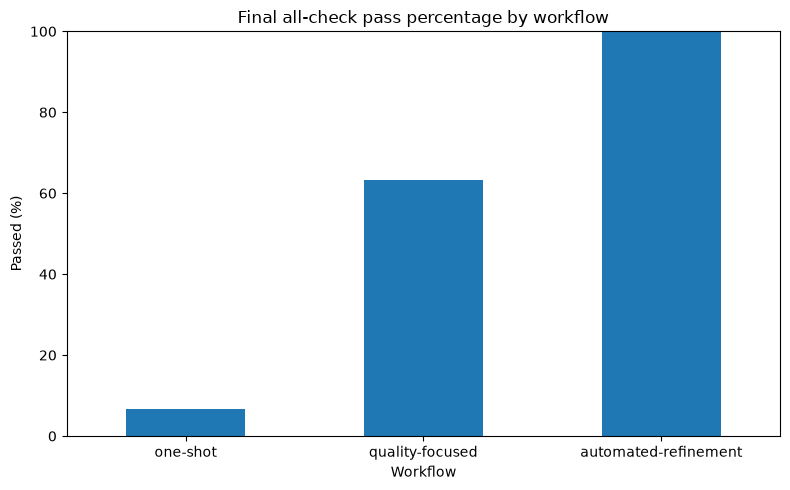

In [42]:
workflow_primary = (
    runs.groupby("workflow", observed=True)["finalAllPassed"]
    .mean()
    .mul(100)
    .sort_values()
)

figure, axis = plt.subplots(figsize=(8, 5))

workflow_primary.plot(
    kind="bar",
    ax=axis,
)

axis.set_title("Final all-check pass percentage by workflow")
axis.set_xlabel("Workflow")
axis.set_ylabel("Passed (%)")
axis.set_ylim(0, 100)
axis.tick_params(axis="x", rotation=0)

figure.tight_layout()
figure.savefig(
    figures_dir / "final_all_pass_percentage_by_workflow.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

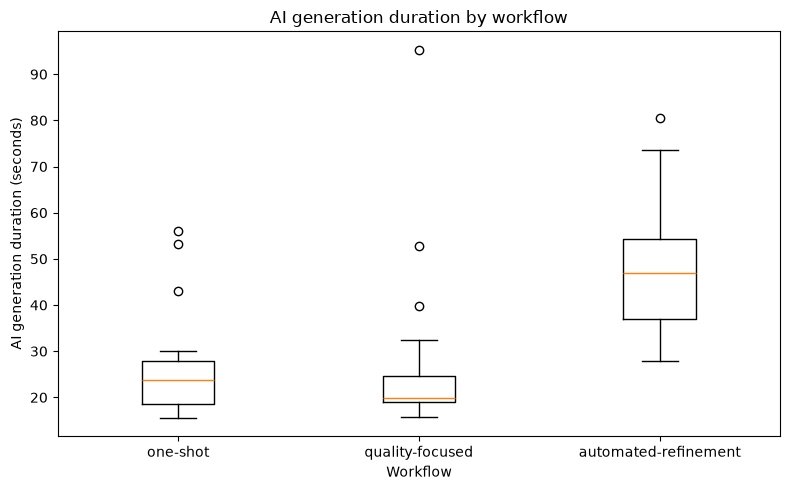

In [43]:
workflow_order = [
    "one-shot",
    "quality-focused",
    "automated-refinement",
]

duration_data = [
    runs.loc[
        runs["workflow"] == workflow,
        "aiGenerationDurationSeconds",
    ].dropna()
    for workflow in workflow_order
]

figure, axis = plt.subplots(figsize=(8, 5))

axis.boxplot(
    duration_data,
    tick_labels=workflow_order,
)

axis.set_title("AI generation duration by workflow")
axis.set_xlabel("Workflow")
axis.set_ylabel("AI generation duration (seconds)")
axis.tick_params(axis="x", rotation=0)

figure.tight_layout()
figure.savefig(
    figures_dir / "ai_generation_duration_by_workflow.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

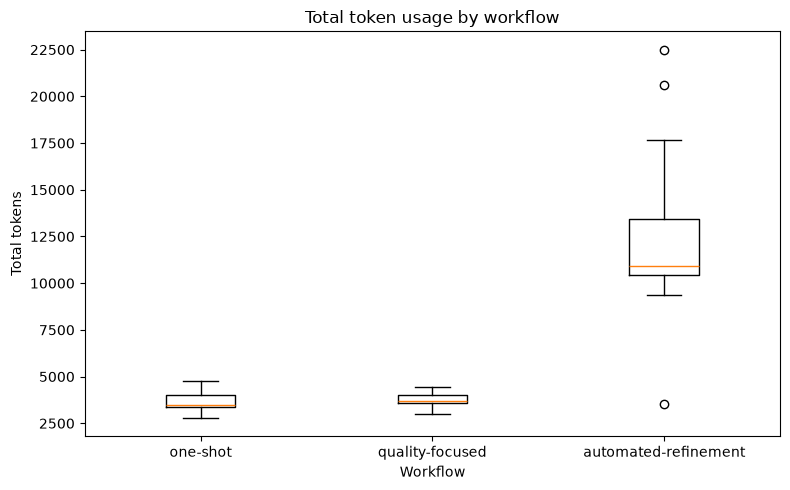

In [44]:
token_data = [
    runs.loc[
        runs["workflow"] == workflow,
        "totalTokens",
    ].dropna()
    for workflow in workflow_order
]

figure, axis = plt.subplots(figsize=(8, 5))

axis.boxplot(
    token_data,
    tick_labels=workflow_order,
)

axis.set_title("Total token usage by workflow")
axis.set_xlabel("Workflow")
axis.set_ylabel("Total tokens")
axis.tick_params(axis="x", rotation=0)

figure.tight_layout()
figure.savefig(
    figures_dir / "total_tokens_by_workflow.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

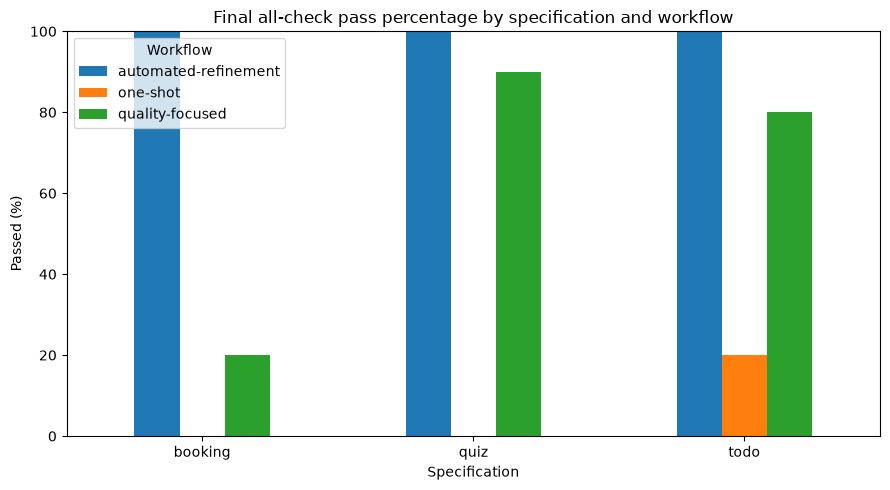

In [45]:
pass_by_cell = (
    runs.groupby(
        ["specificationId", "workflow"],
        observed=True,
    )["finalAllPassed"]
    .mean()
    .mul(100)
    .unstack()
)

figure, axis = plt.subplots(figsize=(9, 5))

pass_by_cell.plot(
    kind="bar",
    ax=axis,
)

axis.set_title("Final all-check pass percentage by specification and workflow")
axis.set_xlabel("Specification")
axis.set_ylabel("Passed (%)")
axis.set_ylim(0, 100)
axis.tick_params(axis="x", rotation=0)
axis.legend(title="Workflow")

figure.tight_layout()
figure.savefig(
    figures_dir / "final_pass_percentage_by_specification_workflow.png",
    dpi=300,
    bbox_inches="tight",
)

plt.show()

In [46]:
expected_tables = [
    "descriptive_overall_pass_outcomes.csv",
    "descriptive_pass_outcomes_by_workflow.csv",
    "descriptive_pass_outcomes_by_cell.csv",
    "descriptive_continuous_by_workflow.csv",
    "descriptive_continuous_by_specification.csv",
    "descriptive_continuous_by_cell.csv",
    "table_primary_quality_outcome.csv",
    "table_efficiency_by_workflow.csv",
    "descriptive_refinement_iterations.csv",
    "descriptive_automated_changes.csv",
    "automated_initial_final_pass_transitions.csv",
]

expected_figures = [
    "final_all_pass_percentage_by_workflow.png",
    "ai_generation_duration_by_workflow.png",
    "total_tokens_by_workflow.png",
    "final_pass_percentage_by_specification_workflow.png",
]

for filename in expected_tables:
    assert (tables_dir / filename).exists(), filename

for filename in expected_figures:
    assert (figures_dir / filename).exists(), filename

assert len(runs) == 90
assert len(automated) == 30

print("Descriptive-analysis outputs: PASSED")

Descriptive-analysis outputs: PASSED
